In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write('{"username":"ayushmishra080106","key":"1f4e50f3d99042fefe83eaef0bead3c1"}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)

os.makedirs("data", exist_ok=True)
!kaggle datasets download -d jessicali9530/celeba-dataset -p data/
!unzip -q data/celeba-dataset.zip -d data/
print("Done")

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:16<00:00, 18.7MB/s]

Done


In [ ]:
import os, time, json, shutil, io
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vgg16, VGG16_Weights
from torchvision.utils import save_image
from torch.nn.utils import spectral_norm
from PIL import Image
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
from google.colab import drive

CFG = {
    "device"      : "cuda" if torch.cuda.is_available() else "cpu",
    "batch_size"  : 8,
    "epochs"      : 30,
    "lr_g"        : 1e-5,
    "lr_d"        : 5e-6,
    "lambda_l1"   : 100,
    "lambda_perc" : 0.1,
    "image_size"  : 256,
    "mask_size"   : 64,
    "channels"    : 3,
    "max_images"  : 5000,
    "save_dir"    : "outputs",
    "data_dir"    : "data/img_align_celeba/img_align_celeba",
    "num_workers" : 2,
}

DRIVE_OUT       = "/content/drive/MyDrive/outputs"
CKPT_FINAL      = os.path.join(CFG["save_dir"], "final_checkpoint.pth")
CKPT_FINAL_BEST = os.path.join(CFG["save_dir"], "final_best.pth")
LOSS_LOG        = os.path.join(CFG["save_dir"], "loss_log_final.json")

os.makedirs(CFG["save_dir"], exist_ok=True)
os.makedirs(DRIVE_OUT, exist_ok=True)
torch.backends.cudnn.benchmark = True
print(f"Device: {CFG['device']} | Batch: {CFG['batch_size']} | Images: {CFG['max_images']}")

Device: cuda | Batch: 8 | Images: 5000


In [ ]:
import shutil

# Ensure the mountpoint is empty before attempting to mount
if os.path.exists('/content/drive') and os.path.isdir('/content/drive') and len(os.listdir('/content/drive')) > 0:
    print("Cleaning up existing /content/drive directory...")
    try:
        # Unmount if already mounted, then remove contents
        if os.path.ismount('/content/drive'):
            drive.flush_and_unmount()
        shutil.rmtree('/content/drive', ignore_errors=True)
        os.makedirs('/content/drive', exist_ok=True)
    except Exception as e:
        print(f"Error cleaning /content/drive: {e}")

drive.mount('/content/drive', force_remount=True)

if os.path.exists(DRIVE_OUT):
    !cp -r /content/drive/MyDrive/outputs /content/
    print("Weights restored:")
    for f in sorted(os.listdir("outputs")):
        mb = os.path.getsize(f"outputs/{f}") / 1e6
        print(f"  {f}  ({mb:.1f} MB)")
else:
    print("No outputs on Drive yet — fresh start")

Cleaning up existing /content/drive directory...
Mounted at /content/drive
Weights restored:
  best_checkpoint.pth  (686.3 MB)
  enhanced_best.pth  (686.4 MB)
  enhanced_checkpoint.pth  (686.4 MB)
  epoch_001.png  (1.0 MB)
  epoch_001_best.png  (1.0 MB)
  epoch_001_enhanced.png  (0.9 MB)
  epoch_001_enhanced_best.png  (0.9 MB)
  epoch_001_final.png  (0.9 MB)
  epoch_001_refine.png  (1.1 MB)
  epoch_001_refine_best.png  (1.1 MB)
  epoch_002.png  (1.1 MB)
  epoch_002_best.png  (1.1 MB)
  epoch_002_enhanced.png  (0.9 MB)
  epoch_002_enhanced_best.png  (0.9 MB)
  epoch_002_final.png  (1.0 MB)
  epoch_002_refine.png  (1.1 MB)
  epoch_002_refine_best.png  (1.1 MB)
  epoch_003.png  (1.0 MB)
  epoch_003_best.png  (1.0 MB)
  epoch_003_enhanced.png  (1.0 MB)
  epoch_003_enhanced_best.png  (1.0 MB)
  epoch_003_final.png  (0.9 MB)
  epoch_003_refine.png  (1.1 MB)
  epoch_003_refine_best.png  (1.1 MB)
  epoch_004.png  (1.1 MB)
  epoch_004_best.png  (1.1 MB)
  epoch_004_enhanced.png  (1.0 MB)
  epoc

In [ ]:
for root, dirs, files in os.walk("data/"):
    jpgs = [f for f in files if f.endswith(".jpg")]
    if jpgs:
        CFG["data_dir"] = root
        print(f"Found {len(jpgs)} images at: {root}")
        break
print(f"data_dir → {CFG['data_dir']}")

In [ ]:
class InpaintingDataset(Dataset):
    def __init__(self, image_dir, max_images):
        self.image_dir  = image_dir
        self.mask_size  = CFG["mask_size"]
        self.image_size = CFG["image_size"]
        self.transform  = transforms.Compose([
            transforms.Resize((self.image_size, self.image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        all_imgs    = sorted([f for f in os.listdir(image_dir)
                              if f.lower().endswith((".jpg",".jpeg",".png"))])
        self.images = all_imgs[:max_images]
        print(f"[Dataset] {len(self.images)} images")

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img    = Image.open(os.path.join(self.image_dir, self.images[idx])).convert("RGB")
        target = self.transform(img)
        masked = target.clone()
        _, H, W = masked.shape
        top  = np.random.randint(0, H - self.mask_size)
        left = np.random.randint(0, W - self.mask_size)
        masked[:, top:top+self.mask_size, left:left+self.mask_size] = -1.0
        return masked, target

In [ ]:
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_dropout=False):
        super().__init__()
        if down:
            self.block = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False),
                nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2, inplace=True))
        else:
            layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
                      nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
            if use_dropout: layers.append(nn.Dropout(0.5))
            self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        f = 64
        self.e1  = nn.Sequential(nn.Conv2d(CFG["channels"], f, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True))
        self.e2  = UNetBlock(f,   f*2)
        self.e3  = UNetBlock(f*2, f*4)
        self.e4  = UNetBlock(f*4, f*8)
        self.e5  = UNetBlock(f*8, f*8)
        self.e6  = UNetBlock(f*8, f*8)
        self.e7  = UNetBlock(f*8, f*8)
        self.bn  = nn.Sequential(nn.Conv2d(f*8, f*8, 4, 2, 1), nn.ReLU(inplace=True))
        self.d1  = UNetBlock(f*8,  f*8, down=False, use_dropout=True)
        self.d2  = UNetBlock(f*16, f*8, down=False, use_dropout=True)
        self.d3  = UNetBlock(f*16, f*8, down=False, use_dropout=True)
        self.d4  = UNetBlock(f*16, f*8, down=False)
        self.d5  = UNetBlock(f*16, f*4, down=False)
        self.d6  = UNetBlock(f*8,  f*2, down=False)
        self.d7  = UNetBlock(f*4,  f,   down=False)
        self.out = nn.Sequential(nn.ConvTranspose2d(f*2, CFG["channels"], 4, 2, 1), nn.Tanh())

    def forward(self, x):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6); b=self.bn(e7)
        d1=self.d1(b)
        d2=self.d2(torch.cat([d1,e7],1)); d3=self.d3(torch.cat([d2,e6],1))
        d4=self.d4(torch.cat([d3,e5],1)); d5=self.d5(torch.cat([d4,e4],1))
        d6=self.d6(torch.cat([d5,e3],1)); d7=self.d7(torch.cat([d6,e2],1))
        return self.out(torch.cat([d7,e1],1))


class DiscriminatorSN(nn.Module):
    def __init__(self):
        super().__init__()
        sn = spectral_norm
        self.model = nn.Sequential(
            sn(nn.Conv2d(CFG["channels"]*2, 64,  4, 2, 1)), nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(64,  128, 4, 2, 1)),               nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(128, 256, 4, 2, 1)),               nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(256, 512, 4, 1, 1)),               nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(512, 1,   4, 1, 1)))
    def forward(self, x, y): return self.model(torch.cat([x, y], 1))

print(f"G params: {sum(p.numel() for p in Generator().parameters()):,}")

G params: 54,414,531


In [ ]:
bce_loss = nn.BCEWithLogitsLoss()
l1_loss  = nn.L1Loss()

# Perceptual loss only — style + TV removed
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters(): p.requires_grad = False
        self.vgg  = vgg.to(CFG["device"])
        self.mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1).to(CFG["device"])
        self.std  = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1).to(CFG["device"])
    def forward(self, fake, real):
        fake = ((fake*0.5+0.5).clamp(0,1) - self.mean) / self.std
        real = ((real*0.5+0.5).clamp(0,1) - self.mean) / self.std
        return F.mse_loss(self.vgg(fake), self.vgg(real))

perceptual_fn = PerceptualLoss()

def compute_psnr(real, fake):
    mse = torch.mean((real-fake)**2)
    return float("inf") if mse==0 else (20*torch.log10(torch.tensor(1.0)/torch.sqrt(mse))).item()

def compute_ssim(real, fake):
    real=(real*0.5+0.5).clamp(0,1); fake=(fake*0.5+0.5).clamp(0,1)
    mu1=real.mean(); mu2=fake.mean()
    s1=((real-mu1)**2).mean(); s2=((fake-mu2)**2).mean()
    s12=((real-mu1)*(fake-mu2)).mean()
    c1,c2=0.01**2,0.03**2
    return ((2*mu1*mu2+c1)*(2*s12+c2)/((mu1**2+mu2**2+c1)*(s1+s2+c2))).item()

def d_loss_fn(D, masked, real, fake):
    pr=D(masked,real); pf=D(masked,fake.detach())
    return (bce_loss(pr,torch.ones_like(pr)) + bce_loss(pf,torch.zeros_like(pf))) * 0.5

def g_loss_fn(D, masked, real, fake):
    pf    = D(masked, fake)
    adv   = bce_loss(pf, torch.ones_like(pf))
    pixel = l1_loss(fake, real) * CFG["lambda_l1"]
    perc  = perceptual_fn(fake, real) * CFG["lambda_perc"]
    return adv+pixel+perc, adv.item(), pixel.item(), perc.item()

print("Losses ready")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 177MB/s]


Losses ready


In [ ]:
def save_sample_grid(masked, fake, real, epoch, tag=""):
    n    = min(4, masked.size(0))
    grid = (torch.cat([masked[:n],fake[:n],real[:n]],0)*0.5+0.5).clamp(0,1)
    save_image(grid, os.path.join(CFG["save_dir"],f"epoch_{epoch:03d}{tag}.png"), nrow=n)

def show_img(path):
    buf = io.BytesIO(open(path,"rb").read())
    display(IPImage(data=buf.read()))

def drive_sync():
    for fname in os.listdir(CFG["save_dir"]):
        shutil.copy2(os.path.join(CFG["save_dir"],fname),
                     os.path.join(DRIVE_OUT,fname))

def load_best_checkpoint(G, D=None):
    """Load best available weights — tries enhanced → refine → base in order."""
    candidates = [
        # os.path.join(CFG["save_dir"], "enhanced_best.pth"),
        # os.path.join(CFG["save_dir"], "final_best.pth"),
        os.path.join(CFG["save_dir"], "final_checkpoint.pth"),
        # os.path.join(CFG["save_dir"], "refine_best.pth"),
        # os.path.join(CFG["save_dir"], "best_checkpoint.pth"),
    ]
    for path in candidates:
        if os.path.exists(path):
            ckpt = torch.load(path, map_location=CFG["device"])
            G.load_state_dict(ckpt["G"] if "G" in ckpt else ckpt)
            if D and "D" in ckpt: D.load_state_dict(ckpt["D"])
            ep   = ckpt.get("epoch","?") if isinstance(ckpt,dict) else "?"
            psnr = ckpt.get("best_psnr", ckpt.get("best_g_loss","?"))
            print(f"Loaded: {os.path.basename(path)} | epoch={ep} | metric={psnr}")
            return ckpt
    print("[Warning] No checkpoint found")
    return None

print("Helpers ready")

Helpers ready


In [ ]:
def train_final():
    print(f"=== Final Training ===")
    print(f"lr_g={CFG['lr_g']} | lr_d={CFG['lr_d']} | images={CFG['max_images']} | batch={CFG['batch_size']}")

    torch.cuda.empty_cache()
    print("CUDA cache cleared.")

    dataset    = InpaintingDataset(CFG["data_dir"], CFG["max_images"])
    dataloader = DataLoader(dataset, batch_size=CFG["batch_size"], shuffle=True,
                            num_workers=2, pin_memory=(CFG["device"] == "cuda"))

    G = Generator().to(CFG["device"])
    D = DiscriminatorSN().to(CFG["device"])

    opt_G = optim.Adam(G.parameters(), lr=CFG["lr_g"], betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=CFG["lr_d"], betas=(0.5, 0.999))

    start_epoch = 1
    best_psnr   = 0.0
    history     = {"g_loss": [], "d_loss": [], "psnr": [], "ssim": [], "perc": []}

    # ── Resume from Drive checkpoint if exists ────────────────────────────────
    DRIVE_FINAL = os.path.join(DRIVE_OUT, "final_checkpoint.pth")
    if os.path.exists(DRIVE_FINAL):
        shutil.copy2(DRIVE_FINAL, CKPT_FINAL)
        ckpt = torch.load(CKPT_FINAL, map_location=CFG["device"])
        G.load_state_dict(ckpt["G"])
        D.load_state_dict(ckpt["D"])
        opt_G.load_state_dict(ckpt["opt_G"])
        opt_D.load_state_dict(ckpt["opt_D"])
        start_epoch = ckpt["epoch"] + 1
        best_psnr   = ckpt.get("best_psnr", 0.0)
        history     = ckpt.get("history", history)
        print(f"[Resume] epoch {ckpt['epoch']} | best PSNR: {best_psnr:.2f} dB")
    else:
        # No final checkpoint — load best available weights
        loaded = False
        for path in [
            os.path.join(CFG["save_dir"], "enhanced_best.pth"),
            os.path.join(CFG["save_dir"], "final_best.pth"),
            os.path.join(CFG["save_dir"], "refine_best.pth"),
            os.path.join(CFG["save_dir"], "best_checkpoint.pth"),
        ]:
            if os.path.exists(path):
                ckpt = torch.load(path, map_location=CFG["device"])
                G.load_state_dict(ckpt["G"] if "G" in ckpt else ckpt)
                if "D" in ckpt: D.load_state_dict(ckpt["D"])
                ep   = ckpt.get("epoch", "?") if isinstance(ckpt, dict) else "?"
                info = ckpt.get("best_psnr", ckpt.get("best_g_loss", "?")) if isinstance(ckpt, dict) else "?"
                print(f"Loaded: {os.path.basename(path)} | epoch={ep} | metric={info}")
                loaded = True
                break
        if not loaded:
            print("[Warning] No checkpoint found — training from scratch")

    epochs = CFG["epochs"]
    print(f"Training from epoch {start_epoch} to {start_epoch + epochs - 1}")

    # ── Fixed validation batch — 16 images, same every epoch ─────────────────
    val_transform = transforms.Compose([
        transforms.Resize((CFG["image_size"], CFG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    val_files = sorted(os.listdir(CFG["data_dir"]))[-200:]  # last 200 = unseen
    val_real  = torch.stack([
        val_transform(Image.open(
            os.path.join(CFG["data_dir"], f)).convert("RGB"))
        for f in val_files[:16]
    ]).to(CFG["device"])

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, start_epoch + epochs):
        G.train(); D.train()
        g_tot = d_tot = perc_tot = 0.0
        t0 = time.time()

        for masked, real in dataloader:
            masked = masked.to(CFG["device"])
            real   = real.to(CFG["device"])
            fake   = G(masked)

            # Discriminator step
            d_loss = d_loss_fn(D, masked, real, fake)
            if d_loss.item() > 0.4:          # healthy threshold
                opt_D.zero_grad()
                d_loss.backward()
                opt_D.step()

            # Generator step x2
            for _ in range(2):
                fake                = G(masked)
                g_loss, adv, pix, perc = g_loss_fn(D, masked, real, fake)
                opt_G.zero_grad()
                g_loss.backward()
                opt_G.step()

            g_tot    += g_loss.item()
            d_tot    += d_loss.item()
            perc_tot += perc

        # ── Metrics on fixed val batch — stable numbers ───────────────────────
        with torch.no_grad():
            cx   = CFG["image_size"] // 2
            half = CFG["mask_size"]  // 2
            vm   = val_real.clone()
            vm[:, :, cx-half:cx+half, cx-half:cx+half] = -1.0
            vf   = G(vm)
            psnr_val = compute_psnr(val_real, vf)
            ssim_val = compute_ssim(val_real, vf)

        n       = len(dataloader)
        avg_g   = g_tot   / n
        avg_d   = d_tot   / n
        is_best = psnr_val > best_psnr

        history["g_loss"].append(avg_g)
        history["d_loss"].append(avg_d)
        history["psnr"].append(psnr_val)
        history["ssim"].append(ssim_val)
        history["perc"].append(perc_tot / n)

        print(f"[{epoch:>3}]  G:{avg_g:.4f}  D:{avg_d:.4f}  "
              f"Perc:{perc_tot/n:.4f}  "
              f"PSNR:{psnr_val:.2f}dB  SSIM:{ssim_val:.3f}  "
              f"{time.time()-t0:.1f}s  {'⭐ BEST' if is_best else ''}")

        # Save visual grid
        with torch.no_grad(): vis = G(masked[:4])
        save_sample_grid(masked, vis, real, epoch, tag="_final")

        # Save checkpoints
        ckpt_data = {
            "epoch"     : epoch,
            "G"         : G.state_dict(),
            "D"         : D.state_dict(),
            "opt_G"     : opt_G.state_dict(),
            "opt_D"     : opt_D.state_dict(),
            "best_psnr" : best_psnr,
            "history"   : history,
            "cfg"       : CFG,
        }
        torch.save(ckpt_data, CKPT_FINAL)

        if is_best:
            best_psnr              = psnr_val
            ckpt_data["best_psnr"] = best_psnr
            torch.save(ckpt_data, CKPT_FINAL_BEST)
            print(f"      ⭐ Best → {best_psnr:.2f} dB saved")

        with open(LOSS_LOG, "w") as f:
            json.dump(history, f)

        # Sync to Drive every epoch
        drive_sync()
        print(f"      Drive synced")

    print(f"\nDone. Best PSNR: {best_psnr:.2f} dB")


# Change CFG before running:
# CFG["batch_size"] = 8
# CFG["max_images"] = 5000
# CFG["epochs"]     = 30
train_final()

=== Final Training ===
lr_g=1e-05 | lr_d=5e-06 | images=5000 | batch=8
CUDA cache cleared.
[Dataset] 5000 images
[Resume] epoch 80 | best PSNR: 29.01 dB
Training from epoch 81 to 110
[ 81]  G:2.0131  D:0.6796  Perc:0.0708  PSNR:26.15dB  SSIM:0.997  511.0s  
      Drive synced
[ 82]  G:2.0126  D:0.6795  Perc:0.0704  PSNR:26.19dB  SSIM:0.997  492.6s  
      Drive synced
[ 83]  G:2.0117  D:0.6796  Perc:0.0704  PSNR:26.37dB  SSIM:0.997  493.5s  
      Drive synced
[ 84]  G:2.0130  D:0.6795  Perc:0.0706  PSNR:25.94dB  SSIM:0.997  513.9s  
      Drive synced
[ 85]  G:2.0043  D:0.6796  Perc:0.0699  PSNR:25.78dB  SSIM:0.997  512.0s  
      Drive synced


Loaded: final_checkpoint.pth | epoch=116 | metric=29.014511108398438
Avg PSNR: 28.63 dB | Avg SSIM: 0.998


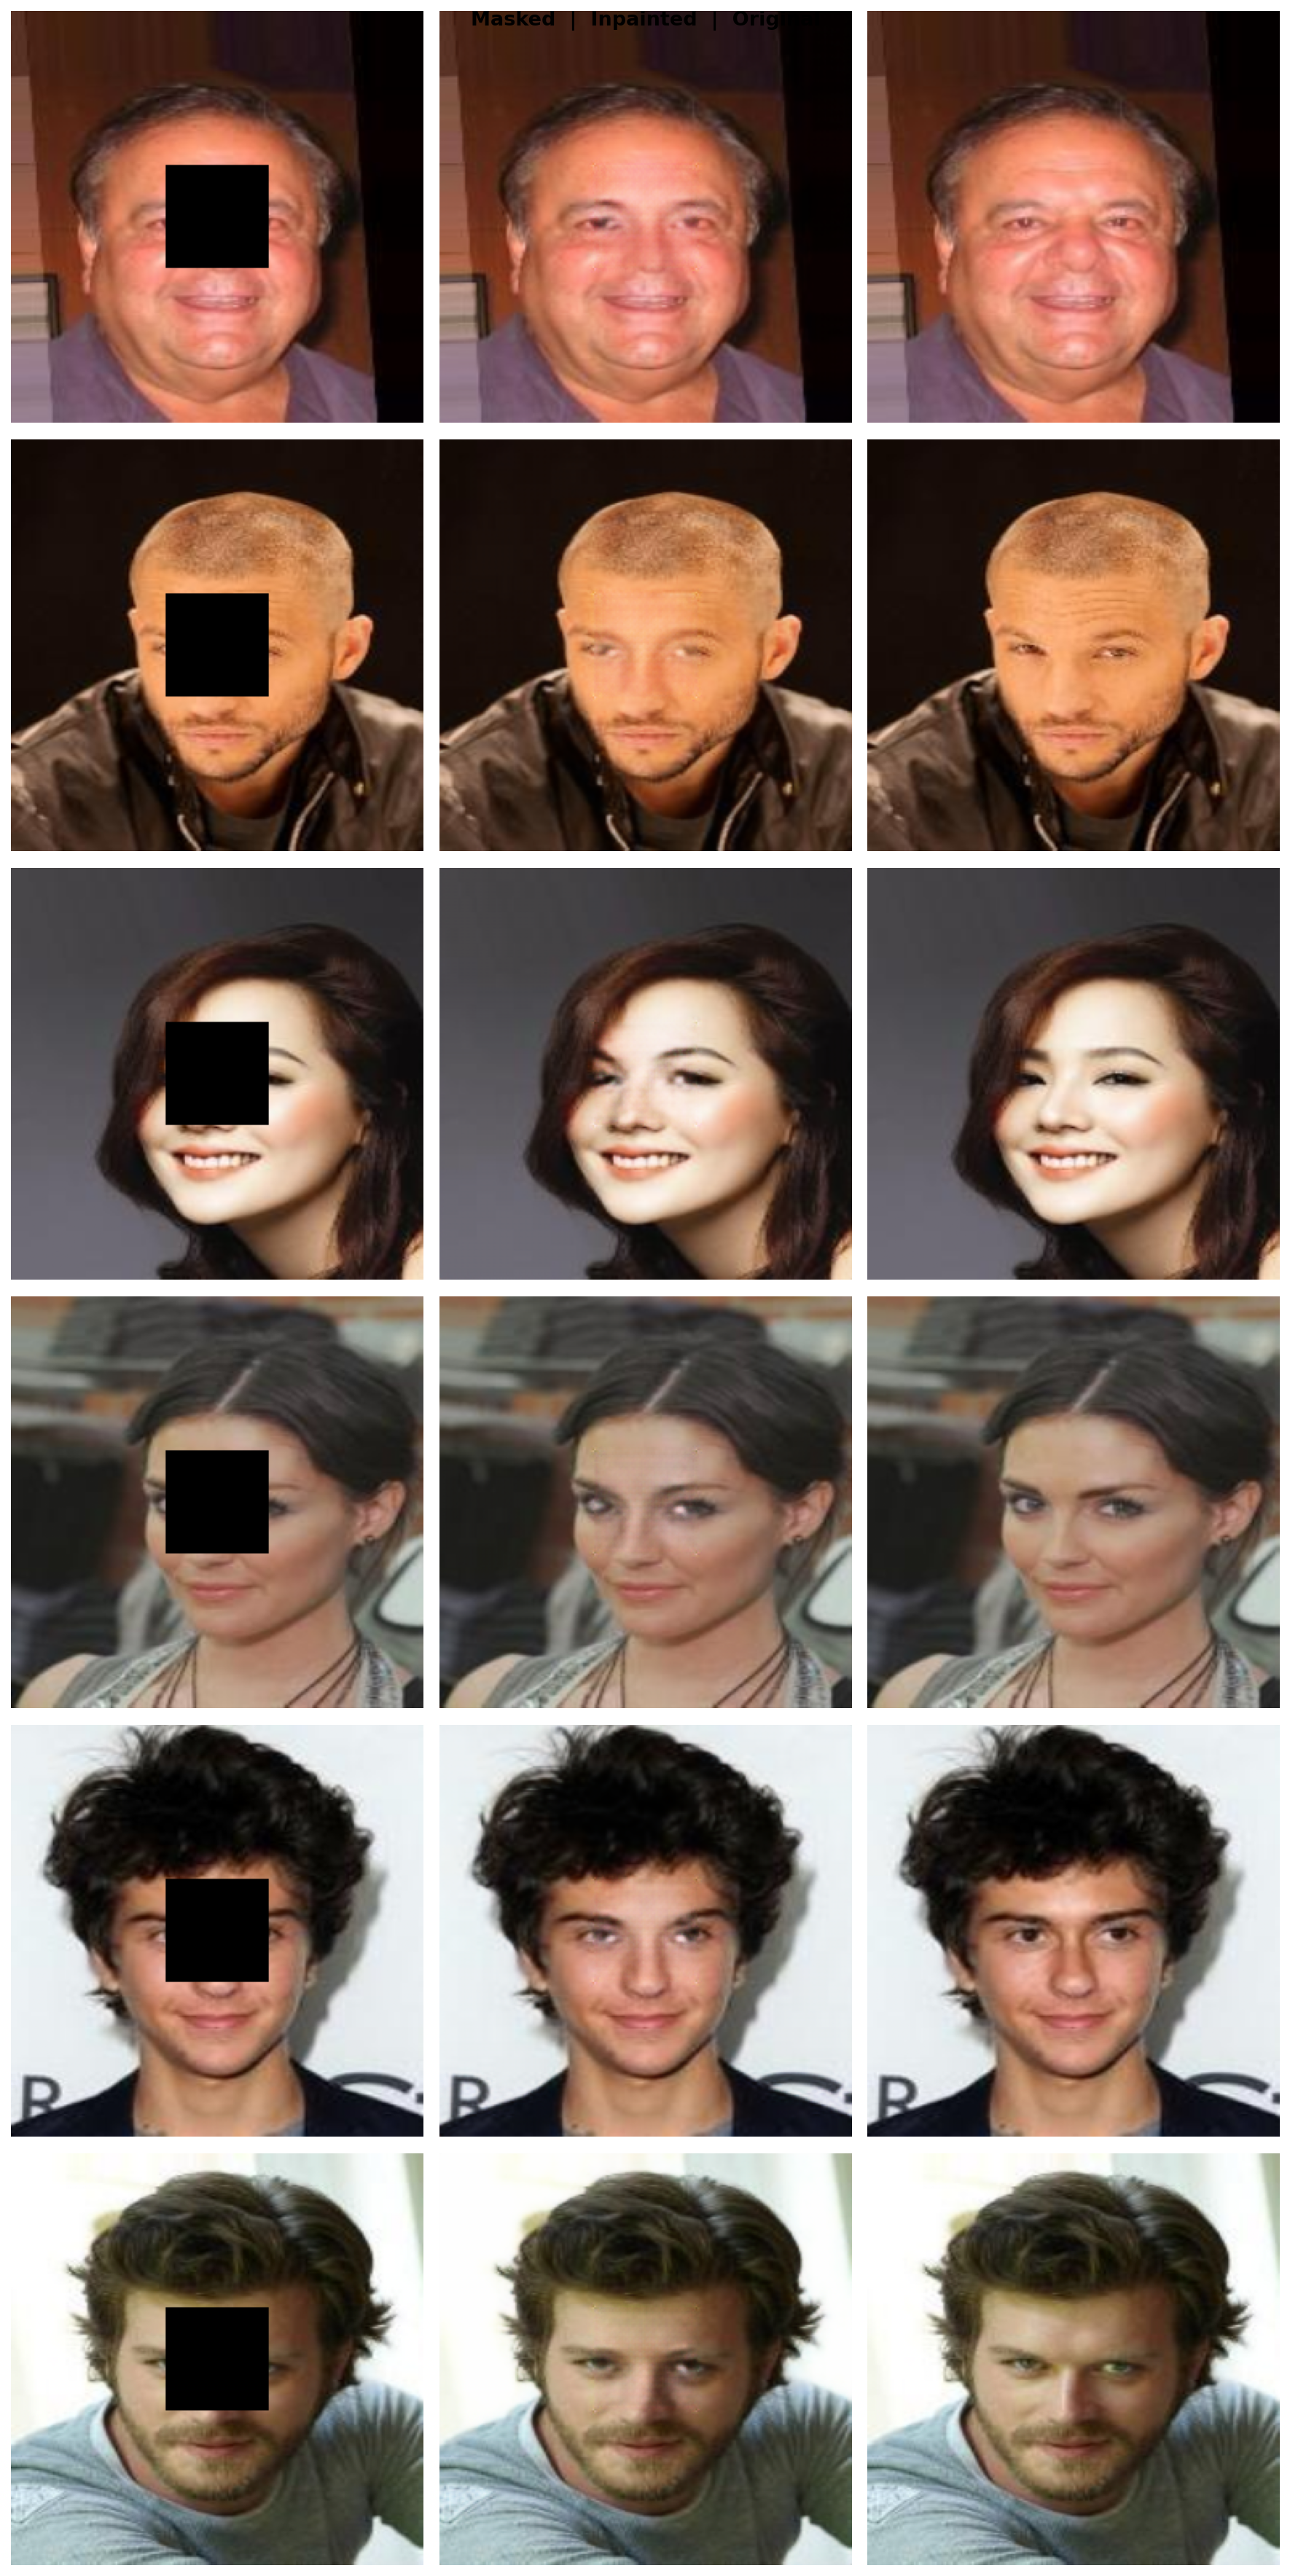

In [ ]:
def test(n=6):
    G = Generator().to(CFG["device"])
    load_best_checkpoint(G)
    G.eval()

    transform = transforms.Compose([
        transforms.Resize((CFG["image_size"],CFG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3),
    ])

    all_imgs = sorted([f for f in os.listdir(CFG["data_dir"])
                       if f.lower().endswith((".jpg",".jpeg",".png"))])
    chosen   = np.random.choice(all_imgs[-5000:], size=n, replace=False)

    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    fig.suptitle("Masked  |  Inpainted  |  Original", fontsize=13, fontweight="bold")
    total_psnr=total_ssim=0.0

    for i, fname in enumerate(chosen):
        tensor = transform(Image.open(
            os.path.join(CFG["data_dir"],fname)).convert("RGB")
        ).unsqueeze(0).to(CFG["device"])

        # center mask for test
        masked = tensor.clone()
        cx=CFG["image_size"]//2; half=CFG["mask_size"]//2
        masked[:,:,cx-half:cx+half,cx-half:cx+half] = -1.0

        with torch.no_grad(): pred = G(masked)

        psnr=compute_psnr(tensor,pred); ssim=compute_ssim(tensor,pred)
        total_psnr+=psnr; total_ssim+=ssim

        for j, im in enumerate([masked[0], pred[0], tensor[0]]):
            axes[i][j].imshow((im.cpu().permute(1,2,0).numpy()*0.5+0.5).clip(0,1))
            axes[i][j].axis("off")
        axes[i][1].set_xlabel(f"PSNR:{psnr:.2f}dB  SSIM:{ssim:.3f}", fontsize=9, color="navy")

    plt.tight_layout()
    out=os.path.join(CFG["save_dir"],"test_result.png")
    plt.savefig(out,dpi=150,bbox_inches="tight"); plt.close()
    print(f"Avg PSNR: {total_psnr/n:.2f} dB | Avg SSIM: {total_ssim/n:.3f}")
    show_img(out)

test()

Loaded final_best.pth — epoch 116 | PSNR: 29.0145


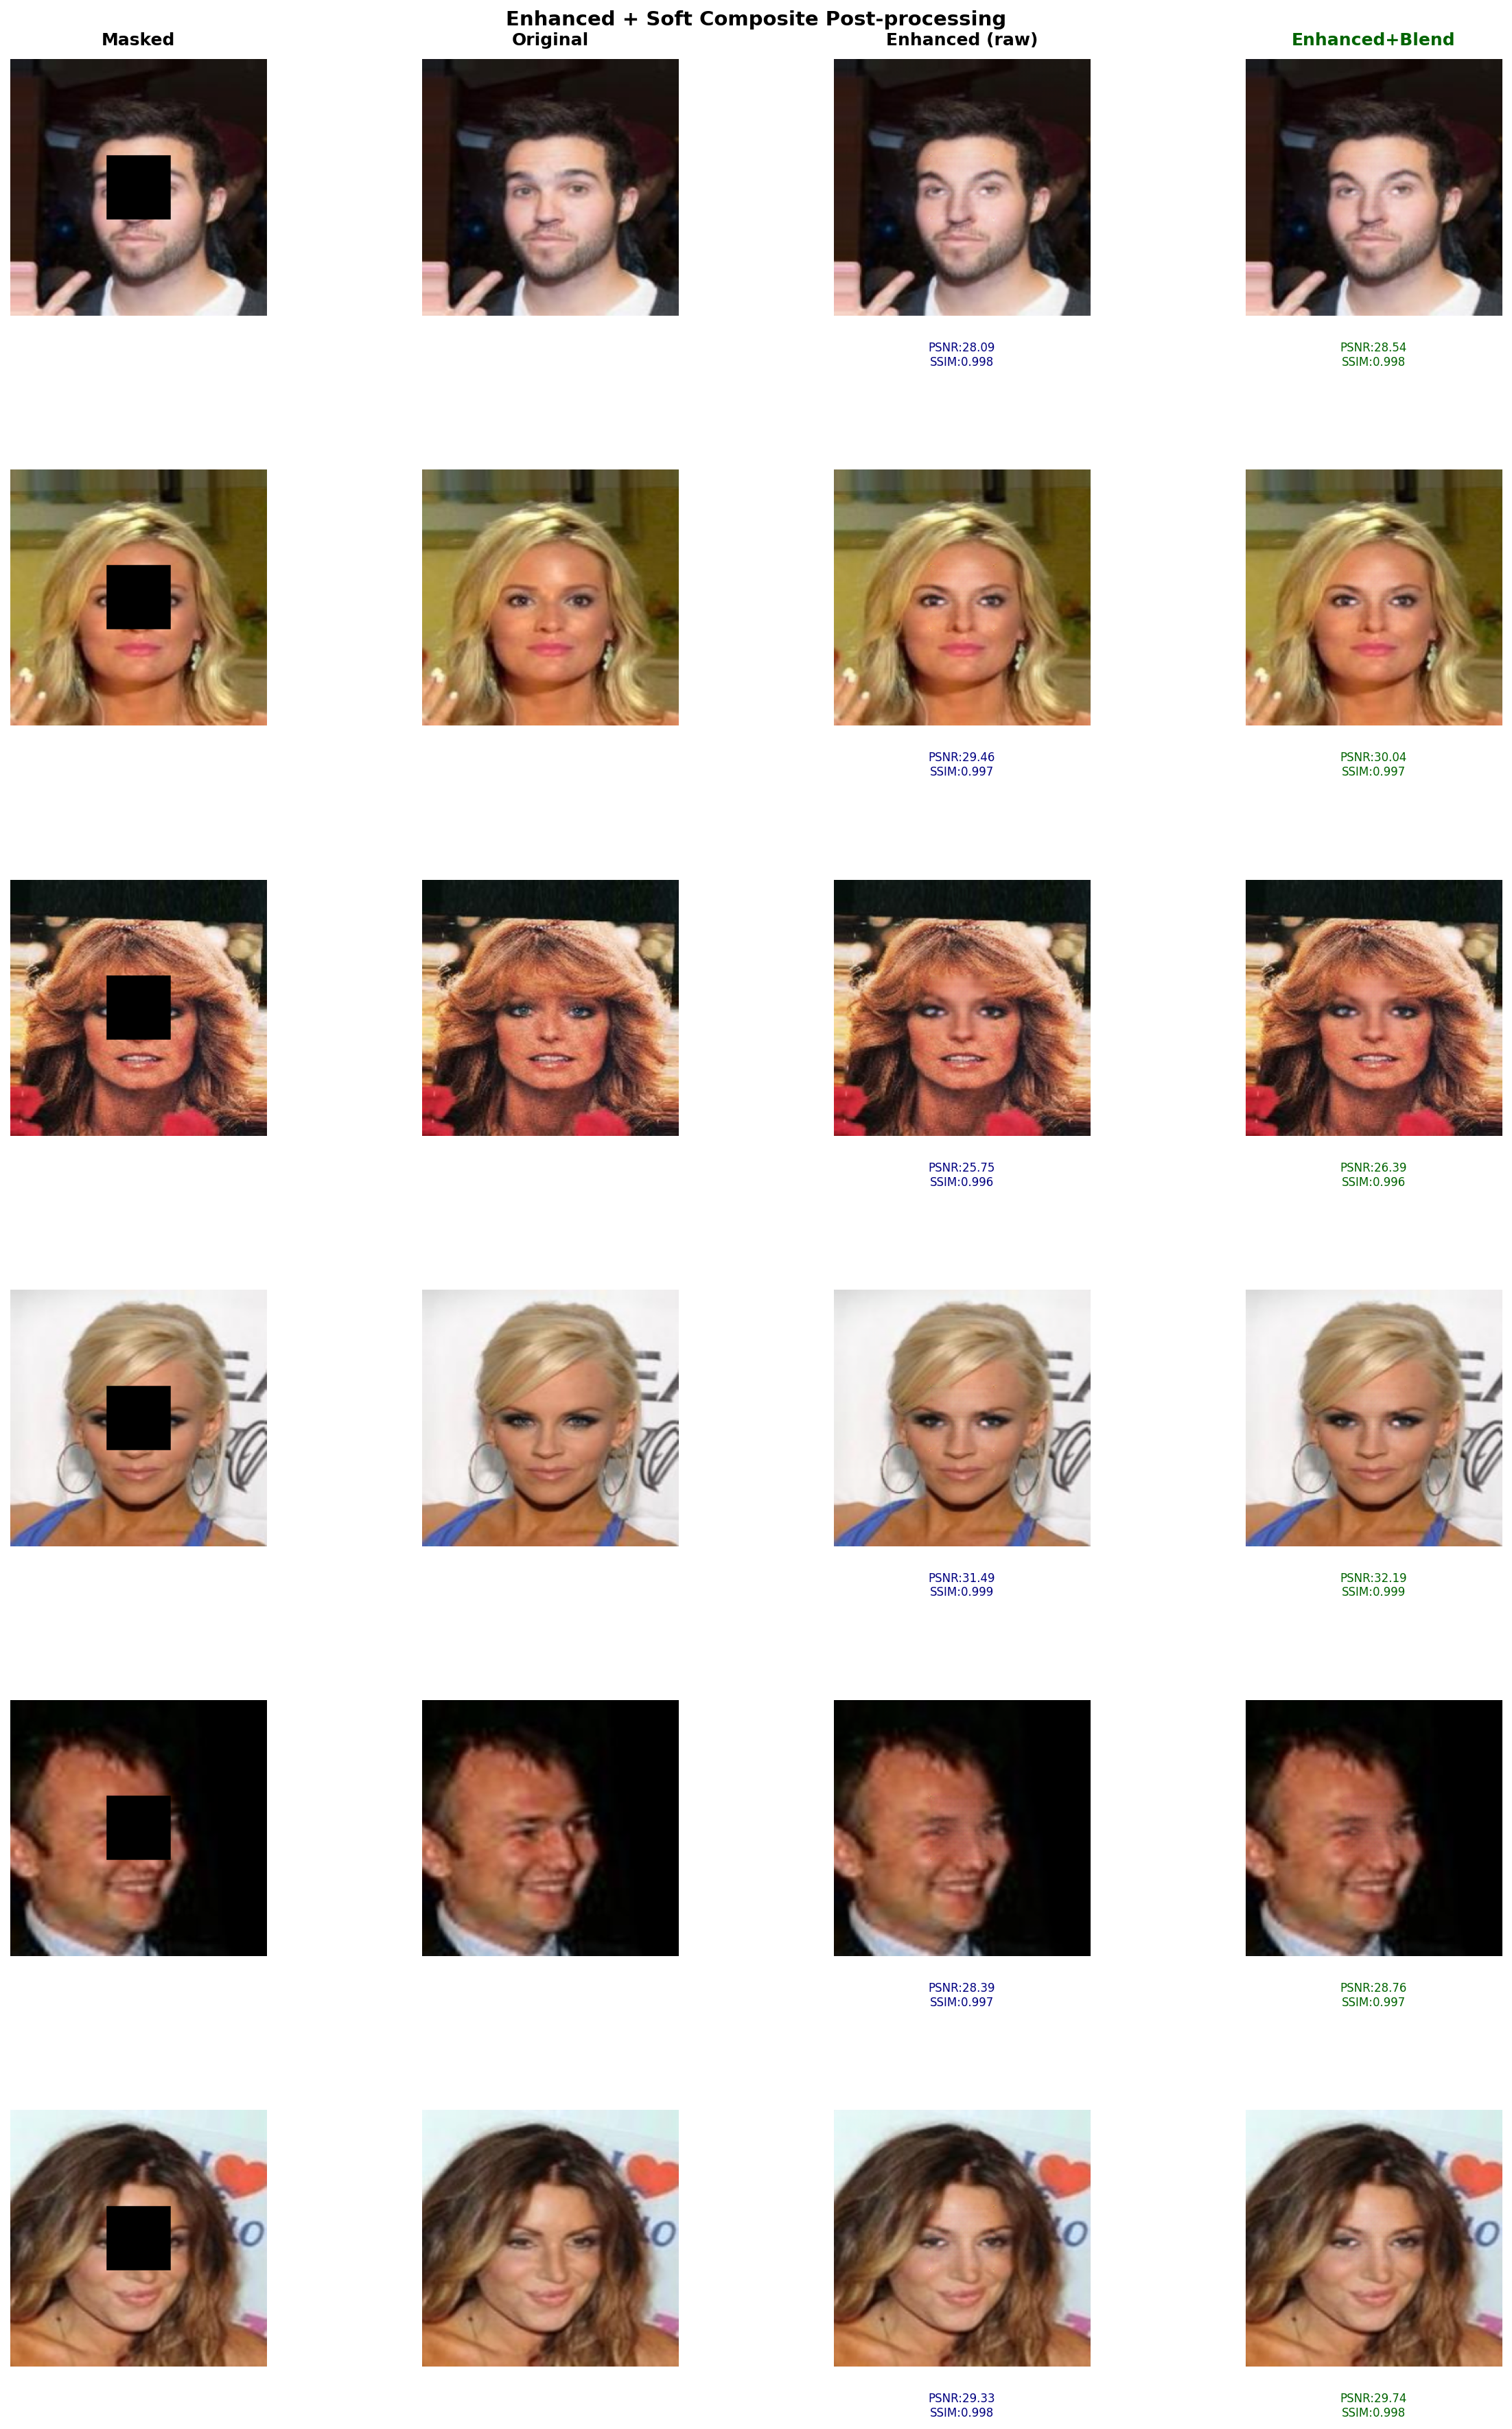

Saved -> outputs/final_enhanced.png

Results Table
--------------------------------------------------------------------------------
Image                  Raw PSNR   Raw SSIM   Blend PSNR   Blend SSIM
--------------------------------------------------------------------------------
107793.jpg                28.09     0.9978        28.54       0.9980
065908.jpg                29.46     0.9970        30.04       0.9973
089616.jpg                25.75     0.9955        26.39       0.9961
130655.jpg                31.49     0.9985        32.19       0.9987
152969.jpg                28.39     0.9968        28.76       0.9971
094094.jpg                29.33     0.9982        29.74       0.9983
--------------------------------------------------------------------------------


In [ ]:
import io
import numpy as np
import torch
import torch.nn.functional as F
import os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image as PILImage
import IPython.display

transform_fn = transforms.Compose([
    transforms.Resize((CFG["image_size"], CFG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def to_display(t):
    return (t.cpu().permute(1,2,0).numpy() * 0.5 + 0.5).clip(0, 1)

def apply_center_mask(t):
    m = t.clone()
    cx = CFG["image_size"] // 2
    half = CFG["mask_size"] // 2
    m[:, cx-half:cx+half, cx-half:cx+half] = -1.0
    return m

def soft_composite(orig_t, pred_t, feather=15):
    cx = CFG["image_size"] // 2
    half = CFG["mask_size"] // 2
    top = cx - half
    H, W = orig_t.shape[1], orig_t.shape[2]

    mask = torch.zeros(1, 1, H, W, device=orig_t.device)
    mask[0, 0, top:top+CFG["mask_size"], top:top+CFG["mask_size"]] = 1.0

    k = feather if feather % 2 == 1 else feather + 1
    mask = F.avg_pool2d(mask, kernel_size=k, stride=1, padding=k//2).clamp(0, 1)

    return pred_t * mask.squeeze(0) + orig_t * (1 - mask.squeeze(0))

# Load best model
REFINE_BEST = "/content/drive/MyDrive/outputs/final_checkpoint.pth"

G = Generator().to(CFG["device"])
ckpt = torch.load(REFINE_BEST, map_location=CFG["device"])
G.load_state_dict(ckpt["G"])
G.eval()

print(f"Loaded final_best.pth — epoch {ckpt['epoch']} | PSNR: {ckpt.get('best_psnr', 0):.4f}")

all_imgs = sorted([
    f for f in os.listdir(CFG["data_dir"])
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

chosen = np.random.choice(all_imgs, size=6, replace=False)

results = []

fig, axes = plt.subplots(6, 4, figsize=(16, 24))
fig.suptitle("Enhanced + Soft Composite Post-processing", fontsize=14, fontweight="bold")

for i, fname in enumerate(chosen):
    tensor = transform_fn(
        PILImage.open(os.path.join(CFG["data_dir"], fname)).convert("RGB")
    ).unsqueeze(0).to(CFG["device"])

    masked = apply_center_mask(tensor[0]).unsqueeze(0)

    with torch.no_grad():
        pred = G(masked)

    blended = soft_composite(tensor[0], pred[0])

    psnr_raw = compute_psnr(tensor, pred)
    ssim_raw = compute_ssim(tensor, pred)

    psnr_blend = compute_psnr(tensor, blended.unsqueeze(0))
    ssim_blend = compute_ssim(tensor, blended.unsqueeze(0))

    results.append([
        fname,
        psnr_raw,
        ssim_raw,
        psnr_blend,
        ssim_blend
    ])

    for j, (img, title, psnr, ssim) in enumerate(zip(
        [masked[0], tensor[0], pred[0], blended],
        ["Masked", "Original", "Enhanced (raw)", "Enhanced+Blend"],
        [None, None, psnr_raw, psnr_blend],
        [None, None, ssim_raw, ssim_blend],
    )):
        axes[i][j].imshow(to_display(img))

        if i == 0:
            axes[i][j].set_title(
                title,
                fontweight="bold",
                color="darkgreen" if j == 3 else "black",
                pad=10
            )

        if psnr is not None:
            axes[i][j].text(
                0.5, -0.10,
                f"PSNR:{psnr:.2f}\nSSIM:{ssim:.3f}",
                transform=axes[i][j].transAxes,
                ha="center",
                va="top",
                fontsize=8,
                color="darkgreen" if j == 3 else "navy"
            )

        axes[i][j].axis("off")

plt.tight_layout()
plt.subplots_adjust(hspace=0.6, wspace=0.08, top=0.96)

out = os.path.join(CFG["save_dir"], "final_enhanced.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()

buf = io.BytesIO(open(out, "rb").read())
IPython.display.display(IPython.display.Image(data=buf.read()))

print(f"Saved -> {out}")

print("\nResults Table")
print("-" * 80)
print(f"{'Image':20s} {'Raw PSNR':>10s} {'Raw SSIM':>10s} {'Blend PSNR':>12s} {'Blend SSIM':>12s}")
print("-" * 80)

for row in results:
    print(
        f"{row[0]:20s} "
        f"{row[1]:10.2f} "
        f"{row[2]:10.4f} "
        f"{row[3]:12.2f} "
        f"{row[4]:12.4f}"
    )

print("-" * 80)